# Supervised Learning Algorithm Effort

In [41]:
# Bringing in the tools needed for loading data, preprocessing,
# training classification models, and evaluating results consistently.

import pandas as pd              # DataFrames (structured tables)
import numpy as np               # Numeric utilities

from sklearn.model_selection import train_test_split  # Create unseen test set

#These allow different preprocessing for numeric vs categorical columns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Pipeline ensures preprocessing + model training happens in one consistent flow
from sklearn.pipeline import Pipeline

# The 3 supervised classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

#Classification evaluation metrics (business-relevant error breakdown)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

In [42]:
# reading in airline data
df = pd.read_csv('airline.csv')

# view dataset to confirm columns and datatypes early
print(df.shape)
print(df.columns)
df.head()

(129880, 23)
Index(['satisfaction', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')


,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


In [43]:
# need consistent labeling

# Business translation:
# - y=1 means "Satisfied"
# - y=0 means "Not satisfied" (neutral or dissatisfied)

# Clean text labels so "Satisfied", "satisfied ", etc. don't become separate categories
df["satisfaction"] = df["satisfaction"].astype(str).str.strip().str.lower()

# Convert to binary outcome for classification
y = (df["satisfaction"] == "satisfied").astype(int)

# Features are everything except the target (prevents leakage)
X = df.drop(columns=["satisfaction"])

dataset is almost split down the middle

In [44]:
# train / test data division
# - Create an unseen test dataset to evaluate how well the
#   model generalizes to new customers.
# - Preserve the satisfied vs dissatisfied ratio in both sets.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Feature set
    y,                  # Target variable
    test_size=0.2,      # 20% of data reserved for testing
    random_state=42,    # Ensures reproducibility
    stratify=y          # Maintains class balance in both splits
)

# Confirm split sizes
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (103904, 22)
Test set size: (25976, 22)


confirmed training and test data split and shape

In [45]:
# data preprocessing with imputation
# Handle missing values (NaNs) so models can train
# Scale numeric features (helps Logistic Regression)
# One-hot encode categorical features (turns text into usable columns)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer  # <-- NEW: handles missing values

# Identify categorical vs numeric columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numeric columns:", list(numeric_cols))

# Fill missing numeric values with the median (robust to outliers)
# Scale numeric values so LR training is stable
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#Fill missing categorical values with the most frequent category
#One-hot encode categories into binary columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

Categorical columns: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Numeric columns: ['Age', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


- used imputation to account for missing data, imputation uses the median value of that category.
- this preserves the integrithy of the data, if we removed, then it could've made the data more biased.

DataFrame.select_dtypes - https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html

StandardScaler - https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

OneHotEncoder- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

ColumnTransformer - https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html
Pipeline - https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

SimpleImputer handles missing values - https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html

Imputation user guide - https://scikit-learn.org/stable/modules/impute.html

Pipeline-ensures consistent preprocessing without leakage- https://scikitlearn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
ColumnTransformer- apply different preprocessing by column type - https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html

In [46]:
# Bring in 3 supervised algorithms
# Define the supervised classification models you will evaluate
# Keep them in a simple dictionary so you can loop through them
# and compare results using the same preprocessing + metrics

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Define supervised models to compare
models = {
    # Logistic Regression: strong, interpretable baseline for binary classification
    # max_iter increased to prevent convergence warnings on larger feature sets
    "Logistic Regression": LogisticRegression(max_iter=1000),

    # Decision Tree: rule-based, non-linear model that can capture interactions
    # random_state ensures results are reproducible
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    # Naive Bayes (GaussianNB): fast probabilistic baseline for numeric features
    # Works well as a benchmark even if independence assumptions are imperfect
    "Naive Bayes": GaussianNB()
}

DecisionTreeClassifier (scikit-learn)- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

GaussianNB (scikit-learn) - https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html

In [47]:
# Training and eval
# Train each model using the same preprocessing workflow
# Generate predictions on the unseen test set
# Compute comparable evaluation metrics for each model
# Print confusion matrices + classification reports for interpretation

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
import numpy as np
import pandas as pd

results = []

for name, clf in models.items():

    # Build a full pipeline so preprocessing is applied consistently
    # and learned from training data only (prevents leakage).
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])

    # Train the model on the training set
    model.fit(X_train, y_train)

    # Predict satisfied vs not satisfied on the test set
    y_pred = model.predict(X_test)

    # If the classifier supports predict_proba, compute ROC-AUC
    # ROC-AUC evaluates how well the model ranks satisfied vs not satisfied across thresholds.
    if hasattr(model.named_steps["classifier"], "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    # Compute classification metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Confusion matrix shows the count of correct/incorrect predictions by class
    cm = confusion_matrix(y_test, y_pred)

    # Store results for later comparison
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc
    })

    # Print detailed evaluation output for interpretation
    print(f"Model: {name}")
    print(cm)
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Not Satisfied", "Satisfied"],
            zero_division=0
        )
    )

Model: Logistic Regression
[[ 9640  2119]
 [ 2119 12098]]
               precision    recall  f1-score   support

Not Satisfied       0.82      0.82      0.82     11759
    Satisfied       0.85      0.85      0.85     14217

     accuracy                           0.84     25976
    macro avg       0.84      0.84      0.84     25976
 weighted avg       0.84      0.84      0.84     25976

Model: Decision Tree
[[10926   833]
 [  741 13476]]
               precision    recall  f1-score   support

Not Satisfied       0.94      0.93      0.93     11759
    Satisfied       0.94      0.95      0.94     14217

     accuracy                           0.94     25976
    macro avg       0.94      0.94      0.94     25976
 weighted avg       0.94      0.94      0.94     25976

Model: Naive Bayes
[[ 9428  2331]
 [ 2366 11851]]
               precision    recall  f1-score   support

Not Satisfied       0.80      0.80      0.80     11759
    Satisfied       0.84      0.83      0.83     14217

     ac

Decision tree - performed the best
- best results for the confusion matrix
- highest precision scores amongst the 3 - correctly predicted satisfied/dissatisfied predictions amongst all satisfied/dissatisfied predictions
- highest recall amongst 3 - correct satisfied/dissatisfied predictions against all actual satisfied customers
- high f1 score - does well identifying satisfied/dissatisfied customers while avoiding false
- in another way, produced the highest number of correct classifications overall, or it minimized both false negative and false positives

Pipeline: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

General estimator API (fit, predict): https://scikit-learn.org/stable/glossary.html#term-fit
Pipeline.fit: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline.fit
Pipeline.predict: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline.predict

predict_proba is described in classifier docs (example logistic regression):
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.predict_proba
roc_auc_score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html

accuracy_score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
precision_score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html
recall_score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html
f1_score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html
confusion_matrix: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
classification_report: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

pandas.DataFrame: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

In [48]:
# model comparison table

import pandas as pd

# Convert collected results from Step 6 into a DataFrame
comparison_table = pd.DataFrame(results)

# Sort by F1-score (balances precision and recall)
comparison_table = comparison_table.sort_values(by="F1", ascending=False)

# Display the comparison table
print(comparison_table)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
1        Decision Tree  0.939406   0.941785  0.947879  0.944822  0.938520
0  Logistic Regression  0.836849   0.850953  0.850953  0.850953  0.909978
2          Naive Bayes  0.819179   0.835637  0.833580  0.834607  0.897194


Table only shows for satisfied results
- Decision Tree scored the highest in all categories
- DT model distinguishes between between satisfied and dissatisfied customers all decision thresholds
- DT AUc showed strong separation capability

F1 score — scikit-learn- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

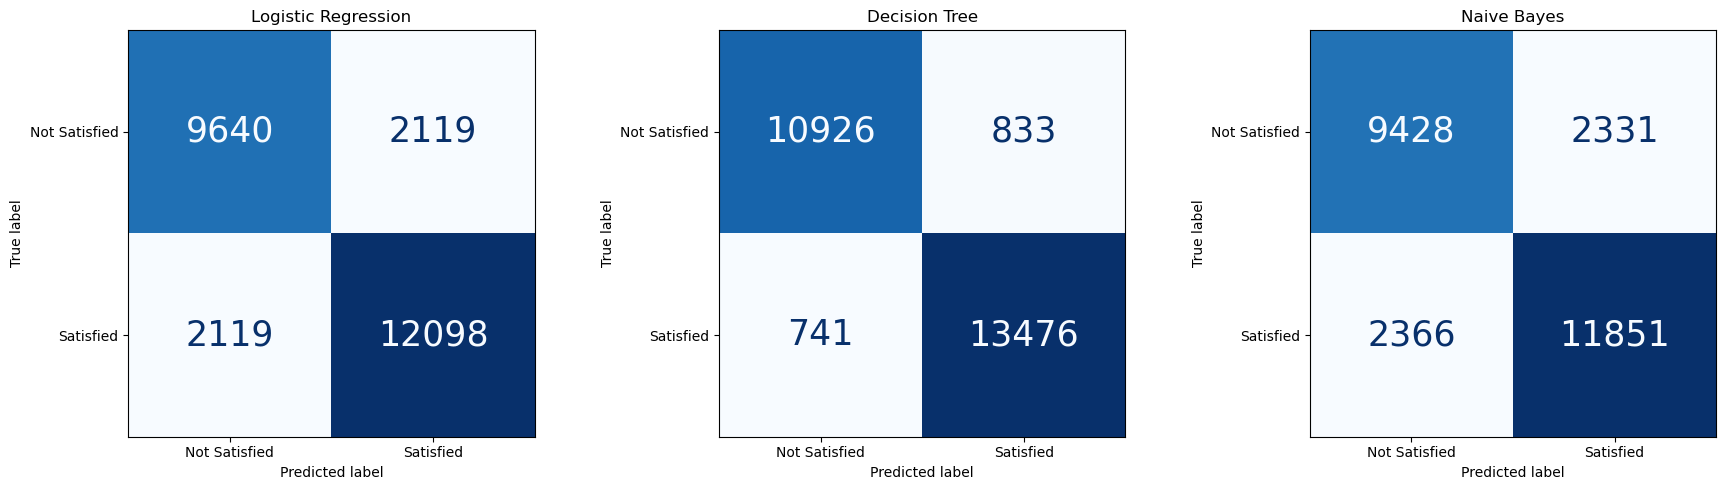

In [49]:
# combined confusion matrix creation

import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create subplot layout (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, clf) in zip(axes, models.items()):

    # Build pipeline
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix on assigned axis
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Satisfied", "Satisfied"]
    )
    disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
    text_kw={"fontsize": 25}  # 👈 increase number size
)

    ax.set_title(name)

# Improve spacing
plt.tight_layout()

plt.show()

# Unsupervised Learning Algorithm Effort

In [50]:
import pandas as pd

# Load airline dataset
df = pd.read_csv("airline.csv")

print(df.shape)
df.head()

(129880, 23)


,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


In [51]:
# Verify clustering features exist
features = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes",
    "Departure/Arrival time convenient",
    "Gate location"
]

df[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 6 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Age                                129880 non-null  int64  
 1   Flight Distance                    129880 non-null  int64  
 2   Departure Delay in Minutes         129880 non-null  int64  
 3   Arrival Delay in Minutes           129487 non-null  float64
 4   Departure/Arrival time convenient  129880 non-null  int64  
 5   Gate location                      129880 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 5.9 MB


- arrival delay has missing values, need to fix

In [52]:
# Pull clustering features into individual arrays (professor-style)
f1 = df["Age"].values
f2 = df["Flight Distance"].values
f3 = df["Departure Delay in Minutes"].values
f4 = df["Arrival Delay in Minutes"].values
f5 = df["Departure/Arrival time convenient"].values
f6 = df["Gate location"].values

In [53]:
import numpy as np

# Combine the feature arrays into a single matrix (rows = passengers, columns = features)
X = np.array(list(zip(f1, f2, f3, f4, f5, f6)))

# Confirm X dimensions: should be (rows, 6 features)
print(X.shape)

(129880, 6)


In [54]:
from sklearn.impute import SimpleImputer

# Impute missing values using the mean
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

- had to account for miss values for code above, this time used "mean" instead of median.

In [55]:
from sklearn.preprocessing import StandardScaler

# Standardize features for distance-based clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

- need to make sure not one feature doesn't dominate, and include all features

In [56]:
X_imputed.shape

(129880, 6)

- imputation worked, all shapes now have the same values

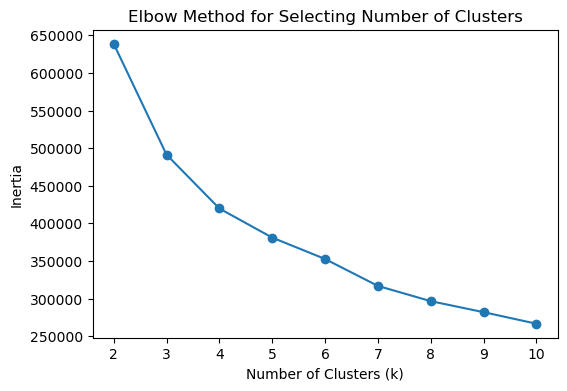

In [57]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Selecting Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

- k should be 4 since there were drastic drops from 2 -4, and after 4, the it seems to be same lengths.

In [58]:
from sklearn.cluster import KMeans

# Set number of clusters
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit model on scaled data
kmeans = kmeans.fit(X_scaled)

# Cluster assignments for each row
labels = kmeans.labels_

# Centroids represent the "average" point of each cluster (in scaled space)
centroids = kmeans.cluster_centers_

print(pd.Series(labels).value_counts().sort_index())


print(centroids)

0     5421
1    40357
2    42193
3    41909
Name: count, dtype: int64
[[-0.05711832  0.58978191  3.67614145  3.67680524  0.01433736  0.01284184]
 [ 0.77359428 -0.5012484  -0.16094642 -0.16288787  0.6826325   0.61550574]
 [-0.86055833  0.51850031 -0.16109193 -0.15978448  0.40420234  0.30070844]
 [ 0.12765436 -0.11492002 -0.15843336 -0.15796204 -1.06868672 -0.89932622]]


- Cluster 0 driven by delays columns

In [59]:
df["cluster"] = labels
df[["cluster"]].head()

,cluster
0,3
1,0
2,3
3,3
4,3


In [60]:
from sklearn.metrics import silhouette_score

sil_scores = {}

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    labels_k = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels_k)

sil_scores

{2: 0.2210002334607333,
 3: 0.22830597584239626,
 4: 0.21606391741926775,
 5: 0.19514283590728226,
 6: 0.20168024282783323}

- could use silhouette score if we look at cluster 3
- diminishing returns after cluster 4

In [61]:
# List the exact clustering columns used (keeps your notebook consistent)
cluster_cols = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes",
    "Departure/Arrival time convenient",
    "Gate location"
]

# Cluster profile: what each segment looks like in the original units
cluster_summary = df.groupby("cluster")[cluster_cols].mean().round(2)


cluster_summary

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Departure/Arrival time convenient,Gate location
cluster,,,,,,
0,38.56,2587.57,154.68,157.00,3.01,3.01
1,51.15,1464.17,8.58,8.81,4.03,3.79
2,26.45,2514.19,8.59,8.94,3.61,3.39
3,41.32,1864.70,8.68,9.01,1.36,1.82


- Cluster 0 - seems to have the highest, followed by cluster 3

In [62]:
# Count how many customers are in each cluster
cluster_counts = df["cluster"].value_counts().sort_index()
cluster_percent = (cluster_counts / len(df) * 100).round(2)

cluster_size_table = pd.DataFrame({
    "count": cluster_counts,
    "percent": cluster_percent
})


cluster_size_table

,count,percent
cluster,,
0,5421,4.17
1,40357,31.07
2,42193,32.49
3,41909,32.27


- interestingly, although cluster 0 has the highest delay for both arrival and departure, it has the lowest.
- however, cluster 1 seems to have the highest count

In [63]:
# Convert centroids back to original scale for interpretation
centroids_unscaled = scaler.inverse_transform(centroids)

centroid_df = pd.DataFrame(centroids_unscaled, columns=cluster_cols).round(2)
centroid_df.index.name = "cluster"


centroid_df

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Departure/Arrival time convenient,Gate location
cluster,,,,,,
0,38.56,2587.18,154.67,156.31,3.01,3.01
1,51.12,1466.57,8.59,8.84,4.03,3.79
2,26.42,2513.97,8.58,8.95,3.61,3.38
3,41.36,1863.37,8.68,9.02,1.36,1.82


- on average, cluster 0 has the longest delays

In [64]:
# Combine mean profiles + size into one table for easier labeling
cluster_profile = cluster_summary.copy()
cluster_profile["count"] = cluster_counts
cluster_profile["percent"] = cluster_percent

cluster_profile

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Departure/Arrival time convenient,Gate location,count,percent
cluster,,,,,,,,
0,38.56,2587.57,154.68,157.00,3.01,3.01,5421,4.17
1,51.15,1464.17,8.58,8.81,4.03,3.79,40357,31.07
2,26.45,2514.19,8.59,8.94,3.61,3.39,42193,32.49
3,41.32,1864.70,8.68,9.01,1.36,1.82,41909,32.27


- Cluster 0 ranks highest in delay, but has the lowest in proportion to the entire data set.
- Cluster 2 is the second biggest - fixing this segment may benefit the other 2 segments given the numbers are generally similar.

In [65]:
# Gender distribution by cluster (post-hoc profiling)
gender_by_cluster = df.groupby("cluster")["Gender"].value_counts(normalize=True).round(3)
gender_by_cluster

cluster  Gender
0        Female    0.500
         Male      0.500
1        Male      0.502
         Female    0.498
2        Male      0.512
         Female    0.488
3        Female    0.536
         Male      0.464
Name: proportion, dtype: float64

- male/female data generally shows an even split.

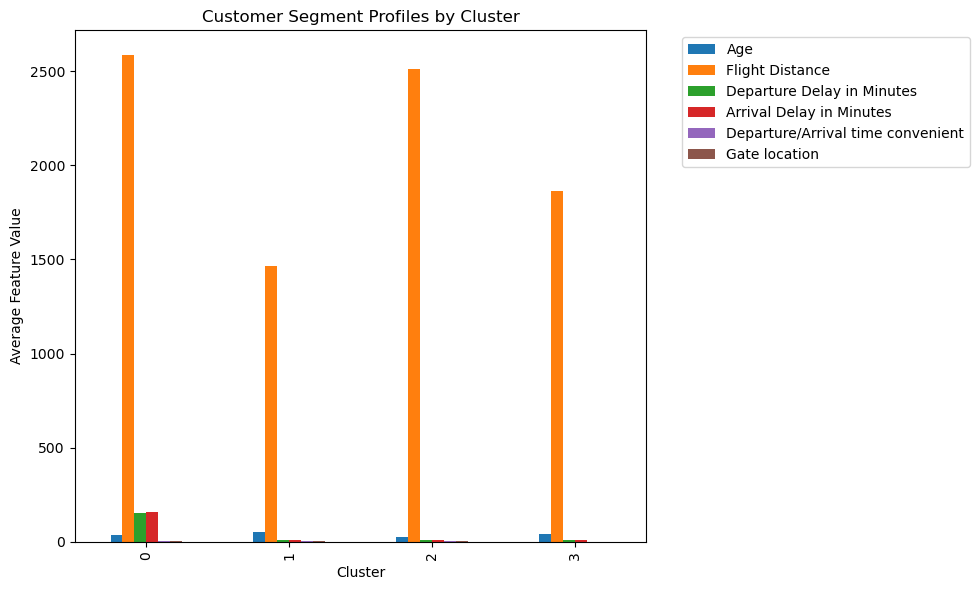

In [66]:
import matplotlib.pyplot as plt

# Plot average feature values by cluster
cluster_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Segment Profiles by Cluster")
plt.ylabel("Average Feature Value")
plt.xlabel("Cluster")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

- different view, but similar takeaways as the table

In [67]:
# Check the exact satisfaction values in the dataset
df["satisfaction"].value_counts()

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64